--- SCENARIO 1: SCANNING NORMAL FILE ---


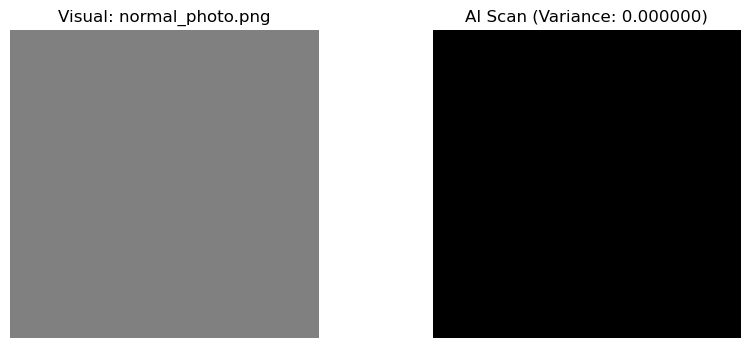

VERDICT for normal_photo.png: [✓] NORMAL - IMAGE VERIFIED CLEAN

--- SCENARIO 2: SCANNING ANOMALOUS FILE ---


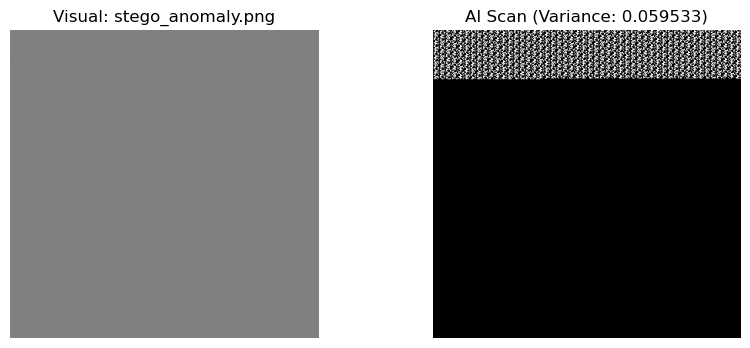

VERDICT for stego_anomaly.png: [!!!] ANOMALY DETECTED - HIDDEN DATA FOUND [!!!]


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- PART A: THE SIMULATED ATTACK (Hiding Data) ---
def hide_secret_data(img_path, message, output_path):
    img = cv2.imread(img_path)
    if img is None:
        img = np.full((400, 400, 3), 128, dtype=np.uint8)
    
    # Convert message to binary (repeated to ensure high variance)
    full_message = message * 500 
    binary_msg = ''.join(format(ord(i), '08b') for i in full_message) + '1111111111111110' 
    
    flat = img.flatten()
    # Injecting bits into the LSB
    for i in range(min(len(binary_msg), len(flat))):
        flat[i] = (flat[i] & 254) | int(binary_msg[i])
    
    res = flat.reshape(img.shape)
    cv2.imwrite(output_path, res)
    return output_path

# --- PART B: THE AI AUDITOR (Detection) ---
def ai_forensic_audit(img_path, threshold=0.0001):
    img = cv2.imread(img_path)
    if img is None:
        return

    # Extract the Least Significant Bit (LSB) plane
    lsb_plane = img[:, :, 0] & 1
    
    # Calculate Statistical Variance (Anomaly Score)
    variance_score = np.var(lsb_plane)
    
    # Plotting results
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Visual: {img_path}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(lsb_plane, cmap='gray')
    plt.title(f"AI Scan (Variance: {variance_score:.6f})")
    plt.axis('off')
    plt.show()

    # Decision Logic
    if variance_score > threshold:
        print(f"VERDICT for {img_path}: [!!!] ANOMALY DETECTED - HIDDEN DATA FOUND [!!!]")
    else:
        print(f"VERDICT for {img_path}: [✓] NORMAL - IMAGE VERIFIED CLEAN")

# --- EXECUTION: TWO SCENARIOS ---

# 1. Setup Files
clean_file = "normal_photo.png"
stego_file = "stego_anomaly.png"
dummy_img = np.full((400, 400, 3), 128, dtype=np.uint8) 
cv2.imwrite(clean_file, dummy_img)

# 2. Run Scenario 1: Normal
print("--- SCENARIO 1: SCANNING NORMAL FILE ---")
ai_forensic_audit(clean_file)

# 3. Run Scenario 2: Anomalies
print("\n--- SCENARIO 2: SCANNING ANOMALOUS FILE ---")
hide_secret_data(clean_file, "ATTACK_PAYLOAD_2026", stego_file)
ai_forensic_audit(stego_file)

Size 1450, Speed 55 -> [✓] SAFE USER
Size 42, Speed 1 -> [!!!] HACKER DETECTED!


D:\SEM4\anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
D:\SEM4\anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
